In [73]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

df_original = pd.read_excel("/content/Security Deposit Claims.xlsx", sheet_name="Security Deposit Claims")
df_features = pd.read_excel("/content/Security Deposit Claims.xlsx", sheet_name="Security Deposit Claims")

#Preprocessing the Data

In [74]:
cols_to_drop_not_reuqired = [
    # generic internal processing data that does not have a strong stake in the max claim, messy text that requires too much nlp processing etc
    'Send to Collections','PM Notification of Claim Received','Open Collections','View PM Information',
    'Tracking Number', 'Property Manager Name','Review Claim Adjudication','Review Tenant Information','Update YRIG Policy Info',
    'Pending Docs from PM','#2 Tenant Employer Phone #','Lease Street Address'
]

columns_to_remove_too_many_nans = [
    'Audit Selection', 'Collection Processed Date', 'Hold Reason',
    'Collected Date', 'Collected Amount', 'Agreed Tenant Settlement Date',
    'Agreed Tenant Settlement', 'PM Explanation','#2 Relationship','#2 Tenant Employer Name','Primary Tenant Employer Name'
]

columns_that_affect_target = [
    'Claim Date','Approval Date','Tenant Collection Status','Collection Status','Status',
    'PM Explanation', 'Hold Reason','Posted Date','Agreed Tenant Settlement','Agreed Tenant Settlement Date',
    'Collected Date', 'Collected Amount','Collection Processed Date'
]

total_cols_to_drop = cols_to_drop_not_reuqired + columns_to_remove_too_many_nans +columns_that_affect_target

df_features = df_features.drop(columns=total_cols_to_drop)


In [75]:
df_features.shape[0]

1244

In [76]:
missing_values = df_features.isnull().sum()
print(missing_values.sort_values(ascending=False))

Lease End Date                 245
Tenant Contacted               244
Termination Type               242
Is there a 3rd Tenant?         237
Amount of Claim                232
Is there a 2nd Tenant?         223
Max Benefit                     46
Monthly Rent                    37
Policy                          36
Approved Benefit Amount         30
Treaty #                        23
Lease Start Date                 8
Move-Out Date                    7
Lease Zip                        6
Lease State                      5
Lease City                       5
Group #                          2
Property Management Company      1
dtype: int64


In [77]:
columns_with_missing_values = [
    'Lease End Date','Tenant Contacted','Termination Type','Is there a 3rd Tenant?','Is there a 2nd Tenant?'
]

df_features.dropna(subset=columns_with_missing_values, inplace=True)

In [78]:
df_features.shape[0]

998

In [79]:
df_features.columns.tolist()

['Lease City',
 'Lease State',
 'Lease Zip',
 'Lease Start Date',
 'Lease End Date',
 'Move-Out Date',
 'Monthly Rent',
 'Amount of Claim',
 'Termination Type',
 'Tenant Contacted',
 'Is there a 2nd Tenant?',
 'Is there a 3rd Tenant?',
 'Property Management Company',
 'Group #',
 'Treaty #',
 'Policy',
 'Max Benefit',
 'Approved Benefit Amount']

In [80]:
cols = ['Lease City', 'Lease State', 'Lease Zip',
        'Tenant Contacted','Is there a 2nd Tenant?','Is there a 3rd Tenant?']

for col in cols:
    unique_count = df_features[col].nunique(dropna=True)
    print(f"{col}: {unique_count} unique values")


Lease City: 252 unique values
Lease State: 45 unique values
Lease Zip: 406 unique values
Tenant Contacted: 7 unique values
Is there a 2nd Tenant?: 2 unique values
Is there a 3rd Tenant?: 2 unique values


In [81]:
df_features['Tenant Contacted'].unique()

array(['Email', 'Email\nMail\nPhone', 'Email\nPhone', 'Email\nMail',
       'Mail', 'Phone', 'Mail\nPhone'], dtype=object)

#Feature Engineering

In [82]:
date_columns = [
    'Lease Start Date', 'Lease End Date', 'Move-Out Date'
]

for col in date_columns:
    df_features[col] = pd.to_datetime(df_features[col], errors='coerce')

#Date feature 1
df_features['lease_duration_days'] = (
    (df_features['Lease End Date'] - df_features['Lease Start Date']).dt.days
)
df_features.loc[df_features['lease_duration_days'] < 0, 'lease_duration_days'] = pd.NA

#Date feature 2
df_features['time_lived_before_moveout'] = (
    (df_features['Move-Out Date'] - df_features['Lease Start Date']).dt.days
)
df_features.loc[df_features['time_lived_before_moveout'] < 0, 'time_lived_before_moveout'] = pd.NA

#Date feature 3
df_features['moved_out_early_flag'] = (
    df_features['Move-Out Date'] < df_features['Lease End Date']
).astype('Int64')

#Date feature 4
df_features['days_remaining_on_lease'] = (
    df_features['Lease End Date'] - df_features['Move-Out Date']
).dt.days
df_features.loc[df_features['days_remaining_on_lease'] < 0, 'days_remaining_on_lease'] = 0

#Date feature 5 and 6
df_features['lease_month_start'] = df_features['Lease Start Date'].dt.month
df_features['lease_year_start'] = df_features['Lease Start Date'].dt.year

columns_to_show = date_columns + [
    'lease_duration_days','time_lived_before_moveout','moved_out_early_flag','days_remaining_on_lease',
]

In [83]:
#Feature 7
df_features['num_tenants'] = 1
df_features['num_tenants'] += df_features['Is there a 2nd Tenant?'].str.lower().eq('yes').fillna(False).astype(int)
df_features['num_tenants'] += df_features['Is there a 3rd Tenant?'].str.lower().eq('yes').fillna(False).astype(int)

#Feature 8
df_features['max_benefit_as_percent_of_rent'] = df_features['Max Benefit'] / df_features['Monthly Rent']
df_features['is_policy_generous'] = (df_features['max_benefit_as_percent_of_rent'] > 1.5).astype(int)


In [84]:
df_features['treaty_policy_combo'] = df_features['Treaty #'].astype(str) + "_" + df_features['Policy'].astype(str)
treaty_freq = df_features['treaty_policy_combo'].value_counts().to_dict()
#Feature 9
df_features['treaty_policy_freq'] = df_features['treaty_policy_combo'].map(treaty_freq)

df_features['group_policy_combo'] = df_features['Group #'].astype(str) + "_" + df_features['Policy'].astype(str)
group_freq = df_features['group_policy_combo'].value_counts().to_dict()
#Feature 10
df_features['group_policy_freq'] = df_features['group_policy_combo'].map(group_freq)

df_features.drop(columns=['treaty_policy_combo', 'group_policy_combo'], inplace=True)

In [85]:
#Feature 11
pm_counts = df_original['Property Management Company'].value_counts().to_dict()
df_features['pm_claim_count'] = df_original['Property Management Company'].map(pm_counts)

#Feature 12
df_features['is_repeat_pm'] = (df_features['pm_claim_count'] > 1).astype(int)


In [86]:
#Feature 13 (Label encoding)
le_term_type = LabelEncoder()
df_features['termination_type_encoded'] = le_term_type.fit_transform(df_features['Termination Type'].astype(str).str.strip())

#Feature 14 (Label encoding)
le_contact = LabelEncoder()
df_features['tenant_contact_encode'] = le_contact.fit_transform(df_features['Tenant Contacted'].astype(str).str.strip())

le_second_tenant = LabelEncoder()
df_features['second_tenant_encoded'] = le_second_tenant.fit_transform(df_features['Is there a 2nd Tenant?'].astype(str).str.strip())

# Feature 17: Label encode 'Is there a 3rd Tenant?'
le_third_tenant = LabelEncoder()
df_features['third_tenant_encoded'] = le_third_tenant.fit_transform(df_features['Is there a 3rd Tenant?'].astype(str).str.strip())

#Feature 14 (Freq encoding) State
state_freq = df_features['Lease State'].value_counts().to_dict()
df_features['lease_state_freq'] = df_features['Lease State'].map(state_freq)

#Feature 18 (Freq encoding) City
city_freq = df_features['Lease City'].value_counts().to_dict()
df_features['lease_city_freq'] = df_features['Lease City'].map(city_freq)

#Feature 19 (Freq encoding) Zip
zip_freq = df_features['Lease Zip'].value_counts().to_dict()
df_features['lease_zip_freq'] = df_features['Lease Zip'].map(zip_freq)


In [87]:
#After feature engineering remove the columns used for it -
remove_processed_cols = ['Lease City','Lease State','Lease Zip','Lease Start Date','Lease End Date',
 'Move-Out Date','Monthly Rent','Termination Type','Tenant Contacted','Is there a 2nd Tenant?',
  'Is there a 3rd Tenant?','Property Management Company','Group #','Treaty #','Policy']

for i in remove_processed_cols:
  df_features.drop(columns=[i], inplace=True)

df_features = df_features[df_features['Max Benefit'].notna()]
df_features = df_features[df_features['time_lived_before_moveout'].notna()]
df_features = df_features[df_features['lease_duration_days'].notna()]
df_features = df_features[df_features['Approved Benefit Amount'].notna()]
df_features = df_features[df_features['Approved Benefit Amount'].apply(lambda x: isinstance(x, (int, float)))]
df_features = df_features[df_features['Amount of Claim'] <= 7000]

df_features.shape[0]

857

In [88]:
for i in df_features:
  Nancount=df_features[i].isna().sum()
  print(i,Nancount)

Amount of Claim 0
Max Benefit 0
Approved Benefit Amount 0
lease_duration_days 0
time_lived_before_moveout 0
moved_out_early_flag 0
days_remaining_on_lease 0
lease_month_start 0
lease_year_start 0
num_tenants 0
max_benefit_as_percent_of_rent 0
is_policy_generous 0
treaty_policy_freq 0
group_policy_freq 0
pm_claim_count 0
is_repeat_pm 0
termination_type_encoded 0
tenant_contact_encode 0
second_tenant_encoded 0
third_tenant_encoded 0
lease_state_freq 0
lease_city_freq 0
lease_zip_freq 0


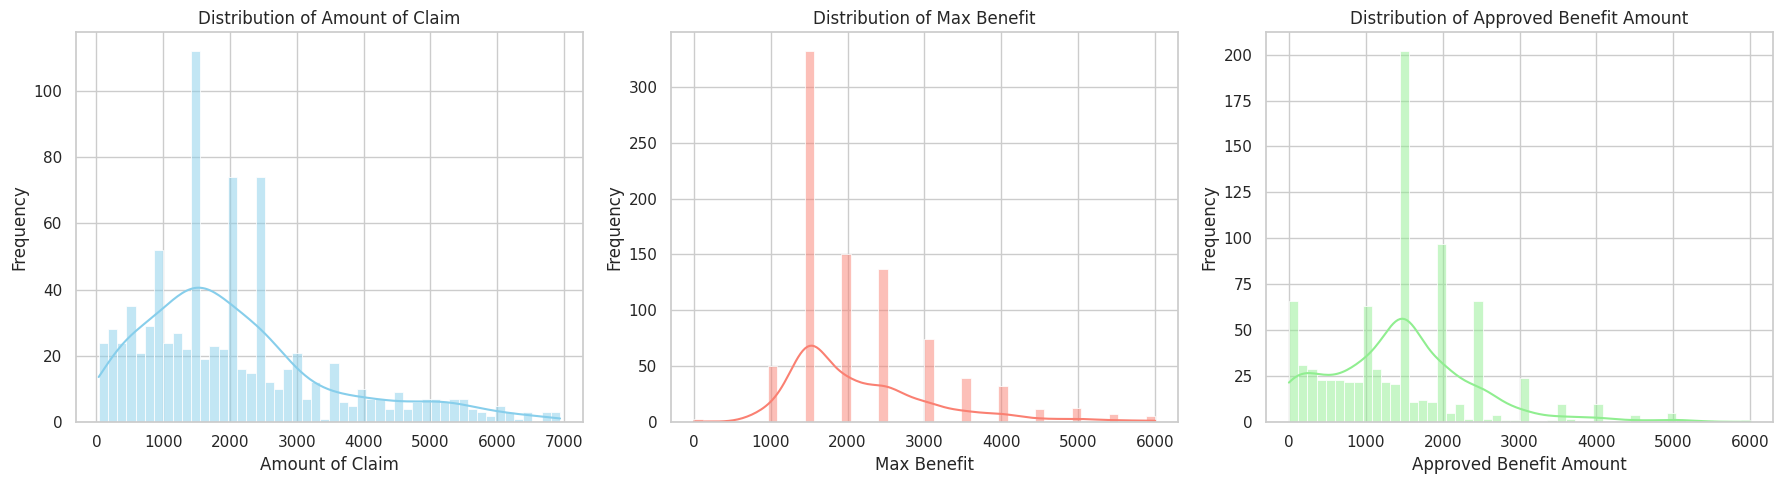

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Create subplots (1 row, 3 columns)
plt.figure(figsize=(18, 5))

# Plot 1: Amount of Claim
plt.subplot(1, 3, 1)
sns.histplot(df_features['Amount of Claim'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Amount of Claim")
plt.xlabel("Amount of Claim")
plt.ylabel("Frequency")

# Plot 2: Max Benefit
plt.subplot(1, 3, 2)
sns.histplot(df_features['Max Benefit'], bins=50, kde=True, color='salmon')
plt.title("Distribution of Max Benefit")
plt.xlabel("Max Benefit")
plt.ylabel("Frequency")

# Plot 3: Approved Benefit Amount
plt.subplot(1, 3, 3)
sns.histplot(df_features['Approved Benefit Amount'], bins=50, kde=True, color='lightgreen')
plt.title("Distribution of Approved Benefit Amount")
plt.xlabel("Approved Benefit Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


#Training the Model

In [89]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

target = 'Approved Benefit Amount'
feature_cols = [col for col in df_features.columns if col != target]

# 💡 Select only numeric columns
X = df_features[feature_cols].select_dtypes(include=[np.number])
y = df_features[target]


In [103]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, LeakyReLU
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.optimizers import Adam

# Scale only numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to float
y = df_features[target].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

he_init = HeNormal()
model = Sequential([
    keras.Input(shape=(X_train.shape[1],)),

    Dense(1024, kernel_initializer=he_init),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.4),

    Dense(512, kernel_initializer=he_init),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, kernel_initializer=he_init),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.25),

    Dense(128, kernel_initializer=he_init),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.25),

    Dense(64, activation='relu'),
    Dense(1)
])


model.compile(
    optimizer=Adam(learning_rate=0.003),
    loss='mean_squared_error',
    metrics=['mae']
)

history = model.fit(
    X_train, y_train,
    validation_split=0.25,
    epochs=100,
    batch_size=40,
    verbose=1
)


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 2864993.5000 - mae: 1416.7289 - val_loss: 2867375.7500 - val_mae: 1458.4823
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 2977267.7500 - mae: 1425.0494 - val_loss: 2527010.2500 - val_mae: 1382.1558
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3035790.0000 - mae: 1420.6877 - val_loss: 2197389.7500 - val_mae: 1291.1920
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 2846262.5000 - mae: 1405.9097 - val_loss: 1958240.2500 - val_mae: 1220.8296
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 2429922.0000 - mae: 1288.5026 - val_loss: 1742500.2500 - val_mae: 1150.7595
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1874908.1250 - mae: 1191.3925 - val_loss: 1287341.5000 - val_mae: 975.5577
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1720764.3750 - mae: 1114.7473 - val_loss: 1245698.5000 - val_mae: 934.3946
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 13

In [106]:
loss, mae = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test).flatten()

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R² Score:", r2)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 265272.5312 - mae: 344.8976 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
MAE: 328.9815979003906
R² Score: 0.7312864631189007


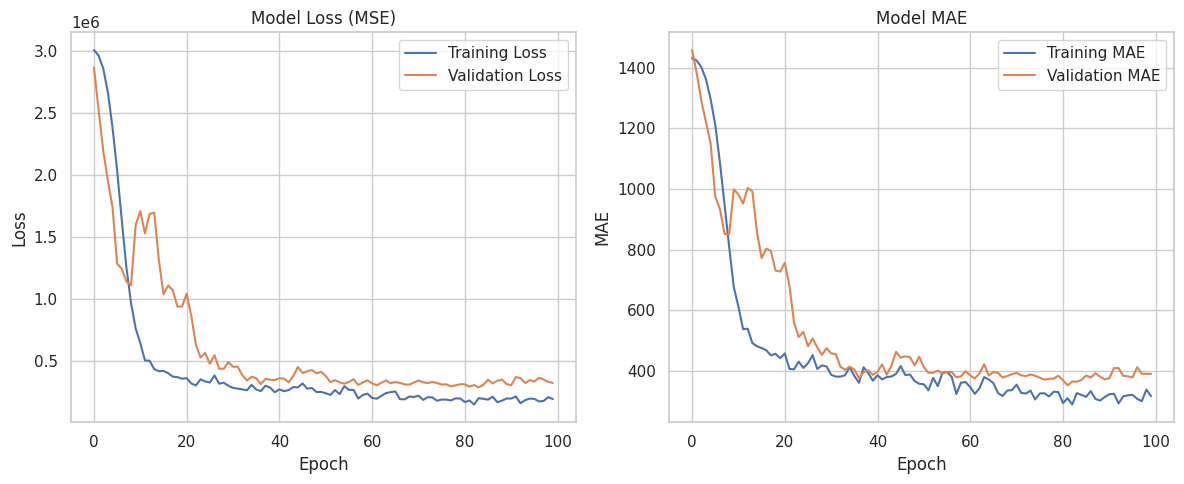

In [107]:
import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
